# 02 - Ad Data Simulation
**Project:** E-Commerce Ad Campaign Analytics  
**Author:** Sahil 

**Description:** Generate realistic ad campaign data. We simulate impressions, clicks, ad spend, attributed orders, and attributed revenue per campaign per day - linked to real Olist product categories.

---
### Why simulate?
The Olist dataset does not include ad spend data. This notebook documents the simulation methodology transparently.

### Simulation logic
| Column | How it's generated |
|---|---|
| `impressions` | Random int, scaled by channel reach |
| `clicks` | `impressions × CTR` where CTR varies by channel |
| `ad_spend` | `clicks × CPC` where CPC varies by channel |
| `attributed_orders` | `clicks × CVR` where CVR varies by channel + category |
| `attributed_revenue` | `attributed_orders × avg_order_value` from real Olist data |

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Set random seed for reproducibility
np.random.seed(42)


# ============================================================================
# Project Paths
# ============================================================================

BASE_DIR = Path(r"C:\Users\F0001215\Jupyter Notebook\ecommerce-ad-analytics")

RAW_DIR = BASE_DIR / "data" / "raw"
PROC_DIR = BASE_DIR / "data" / "processed"


print("Libraries Imported Successfully")
print(f"Raw Data Folder      : {RAW_DIR}")
print(f"Processed Data Folder: {PROC_DIR}")

Libraries Imported Successfully
Raw Data Folder      : C:\Users\F0001215\Jupyter Notebook\ecommerce-ad-analytics\data\raw
Processed Data Folder: C:\Users\F0001215\Jupyter Notebook\ecommerce-ad-analytics\data\processed


---
## 1. Load Real Category & Revenue Data from Olist

In [2]:
# ============================================================================
# Load Master Dataset
# ============================================================================

master = pd.read_csv(PROC_DIR / "master_orders.csv",parse_dates=["order_purchase_timestamp"])


# ============================================================================
# Calculate Average Order Value (AOV) by Product Category
# ============================================================================

aov_by_category = (
    master
    .groupby("product_category_eng", as_index=False)["payment_value"]
    .mean()
    .round(2)
    .rename(columns={"payment_value": "avg_order_value"})
)


# ============================================================================
# Select Top 20 Product Categories
# ============================================================================

top_categories = (
    master["product_category_eng"]
    .value_counts()
    .head(20)
    .index
)

aov_by_category = aov_by_category[aov_by_category["product_category_eng"].isin(top_categories)]


# ============================================================================
# Summary
# ============================================================================

print(f"Top Categories      : {len(top_categories)}")
print(
    f"Average Order Value : "
    f"R${aov_by_category['avg_order_value'].min():.2f}"
    f" - "
    f"R${aov_by_category['avg_order_value'].max():.2f}"
)

display(
    aov_by_category
    .sort_values("avg_order_value", ascending=False)
    .head(10)
)

Top Categories      : 20
Average Order Value : R$83.50 - R$379.48


,product_category_eng,avg_order_value
57,office_furniture,379.48
72,watches_gifts,189.97
15,computers_accessories,185.06
20,cool_stuff,183.91
5,auto,177.07
42,garden_tools,168.80
39,furniture_decor,168.18
53,luggage_accessories,163.94
7,bed_bath_table,152.81
43,health_beauty,151.38


---
## 2. Define Channel Parameters
Each channel has realistic CTR, CVR, and CPC ranges based on industry benchmarks.

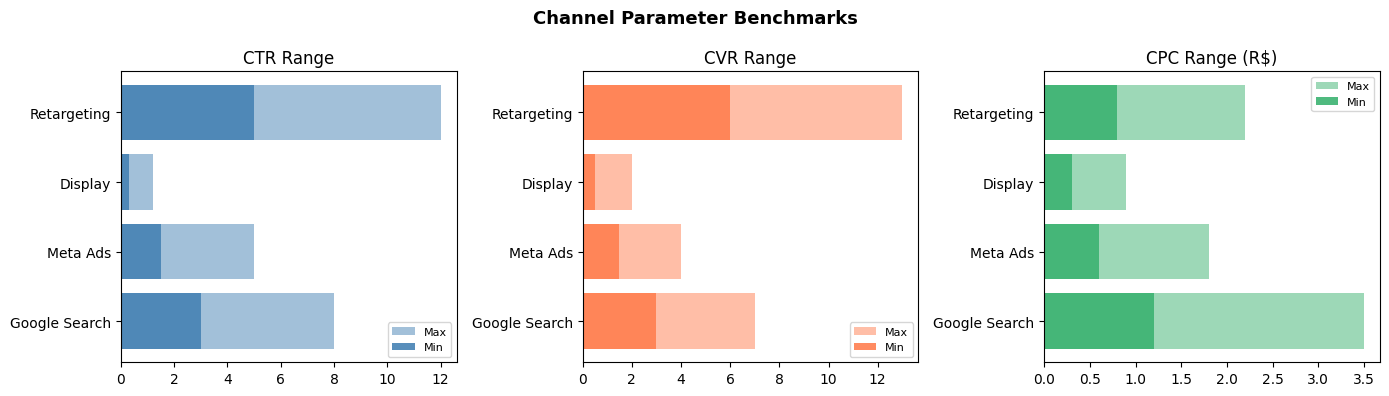

Channel benchmarks visualised


In [3]:
# Channel performance parameters (based on e-commerce industry benchmarks)
CHANNELS = {
    'Google Search': {
        'impression_range' : (8_000,  80_000),
        'ctr_range'        : (0.030,  0.080),   # High intent → high CTR
        'cpc_range'        : (1.20,   3.50),
        'cvr_range'        : (0.030,  0.070),   # High intent → high CVR
        'n_campaigns'      : 6
    },
    'Meta Ads': {
        'impression_range' : (30_000, 200_000),
        'ctr_range'        : (0.015,  0.050),   # Broader audience
        'cpc_range'        : (0.60,   1.80),
        'cvr_range'        : (0.015,  0.040),
        'n_campaigns'      : 6
    },
    'Display': {
        'impression_range' : (50_000, 500_000),  # High volume, low quality
        'ctr_range'        : (0.003,  0.012),
        'cpc_range'        : (0.30,   0.90),
        'cvr_range'        : (0.005,  0.020),   # Low intent
        'n_campaigns'      : 5
    },
    'Retargeting': {
        'impression_range' : (5_000,  40_000),   # Smaller audience
        'ctr_range'        : (0.050,  0.120),   # Already seen the brand
        'cpc_range'        : (0.80,   2.20),
        'cvr_range'        : (0.060,  0.130),   # High CVR — warm audience
        'n_campaigns'      : 5
    }
}

# Visualise channel benchmarks
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Channel Parameter Benchmarks', fontsize=13, fontweight='bold')

metrics = ['ctr_range', 'cvr_range', 'cpc_range']
labels  = ['CTR Range', 'CVR Range', 'CPC Range (R$)']
colors  = ['steelblue', 'coral', 'mediumseagreen']

for ax, metric, label, color in zip(axes, metrics, labels, colors):
    channels = list(CHANNELS.keys())
    mins = [CHANNELS[c][metric][0]*100 if 'cpc' not in metric else CHANNELS[c][metric][0] for c in channels]
    maxs = [CHANNELS[c][metric][1]*100 if 'cpc' not in metric else CHANNELS[c][metric][1] for c in channels]
    ax.barh(channels, maxs, color=color, alpha=0.5, label='Max')
    ax.barh(channels, mins, color=color, alpha=0.9, label='Min')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print('Channel benchmarks visualised')

---
## 3. Generate Campaign Data

In [4]:
# Date range: match Olist order data (Sep 2016 – Oct 2018)
date_range = pd.date_range(start='2017-01-01', end='2018-09-30', freq='D')

rows = []
campaign_counter = 1

for channel, params in CHANNELS.items():
    for i in range(params['n_campaigns']):

        # Assign a category to this campaign
        category = np.random.choice(top_categories)
        avg_order_value = aov_by_category[
            aov_by_category['product_category_eng'] == category
        ]['avg_order_value'].values[0]

        campaign_id   = f'CMP_{campaign_counter:03d}'
        campaign_name = f'{category.replace("_"," ").title()} — {channel} #{i+1}'

        # Fix CTR/CVR/CPC for this campaign (consistent campaign-level performance)
        base_ctr = np.random.uniform(*params['ctr_range'])
        base_cvr = np.random.uniform(*params['cvr_range'])
        base_cpc = np.random.uniform(*params['cpc_range'])

        for date in date_range:
            # Add daily noise (±15%) to simulate natural variance
            day_noise = np.random.uniform(0.85, 1.15)

            # Weekday uplift: Mon–Thu get 10% more impressions
            weekday_mult = 1.10 if date.weekday() < 4 else 0.90

            impressions = int(
                np.random.randint(*params['impression_range'])
                * day_noise * weekday_mult
            )
            clicks      = max(1, int(impressions * base_ctr * day_noise))
            ad_spend    = round(clicks * base_cpc * day_noise, 2)
            attr_orders = max(0, int(clicks * base_cvr * day_noise))
            attr_revenue= round(attr_orders * avg_order_value * np.random.uniform(0.90, 1.10), 2)

            rows.append({
                'date'               : date.date(),
                'campaign_id'        : campaign_id,
                'campaign_name'      : campaign_name,
                'channel'            : channel,
                'product_category_eng': category,
                'impressions'        : impressions,
                'clicks'             : clicks,
                'ad_spend'           : ad_spend,
                'attributed_orders'  : attr_orders,
                'attributed_revenue' : attr_revenue
            })

        campaign_counter += 1

ad_df = pd.DataFrame(rows)
print(f'   Ad campaign data generated')
print(f'   Rows          : {len(ad_df):,}')
print(f'   Campaigns     : {ad_df["campaign_id"].nunique()}')
print(f'   Date range    : {ad_df["date"].min()} → {ad_df["date"].max()}')
print(f'   Channels      : {ad_df["channel"].unique().tolist()}')
ad_df.head(3)

   Ad campaign data generated
   Rows          : 14,036
   Campaigns     : 22
   Date range    : 2017-01-01 → 2018-09-30
   Channels      : ['Google Search', 'Meta Ads', 'Display', 'Retargeting']


,date,campaign_id,campaign_name,channel,product_category_eng,impressions,clicks,ad_spend,attributed_orders,attributed_revenue
0,2017-01-01,CMP_001,Watches Gifts — Google Search #1,Google Search,watches_gifts,13211,949,2923.17,36,6368.39
1,2017-01-02,CMP_001,Watches Gifts — Google Search #1,Google Search,watches_gifts,49741,3012,7820.52,97,17110.90
2,2017-01-03,CMP_001,Watches Gifts — Google Search #1,Google Search,watches_gifts,83727,6111,19120.01,238,49462.05


---
## 4. Validate Simulated Data

In [5]:
# Sanity check: compute derived metrics
summary = ad_df.groupby('channel').agg(
    impressions      = ('impressions',       'sum'),
    clicks           = ('clicks',            'sum'),
    ad_spend         = ('ad_spend',          'sum'),
    attributed_orders= ('attributed_orders', 'sum'),
    attributed_revenue=('attributed_revenue','sum')
).assign(
    ctr_pct = lambda d: (d['clicks'] / d['impressions'] * 100).round(2),
    cvr_pct = lambda d: (d['attributed_orders'] / d['clicks'] * 100).round(2),
    roas    = lambda d: (d['attributed_revenue'] / d['ad_spend']).round(2),
    cpa     = lambda d: (d['ad_spend'] / d['attributed_orders']).round(2)
)

print('Channel-level validation summary:')
display(summary[['ctr_pct','cvr_pct','roas','cpa','ad_spend','attributed_revenue']])

# Key checks
assert ad_df['clicks'].le(ad_df['impressions']).all(), 'Clicks exceed impressions!'
assert ad_df['attributed_orders'].le(ad_df['clicks']).all(), 'Orders exceed clicks!'
assert (ad_df['ad_spend'] > 0).all(), 'Zero spend found!'
print('\n All validation checks passed')

Channel-level validation summary:


,ctr_pct,cvr_pct,roas,cpa,ad_spend,attributed_revenue
channel,,,,,,
Display,0.80,1.40,5.01,41.28,4105241.21,2.058225e+07
Google Search,5.85,4.52,3.05,55.71,24883931.85,7.594408e+07
Meta Ads,4.09,2.62,3.04,47.33,22538456.03,6.849848e+07
Retargeting,8.67,9.78,11.11,18.00,11173290.23,1.241733e+08



 All validation checks passed


---
## 5. Visualise Simulated Data

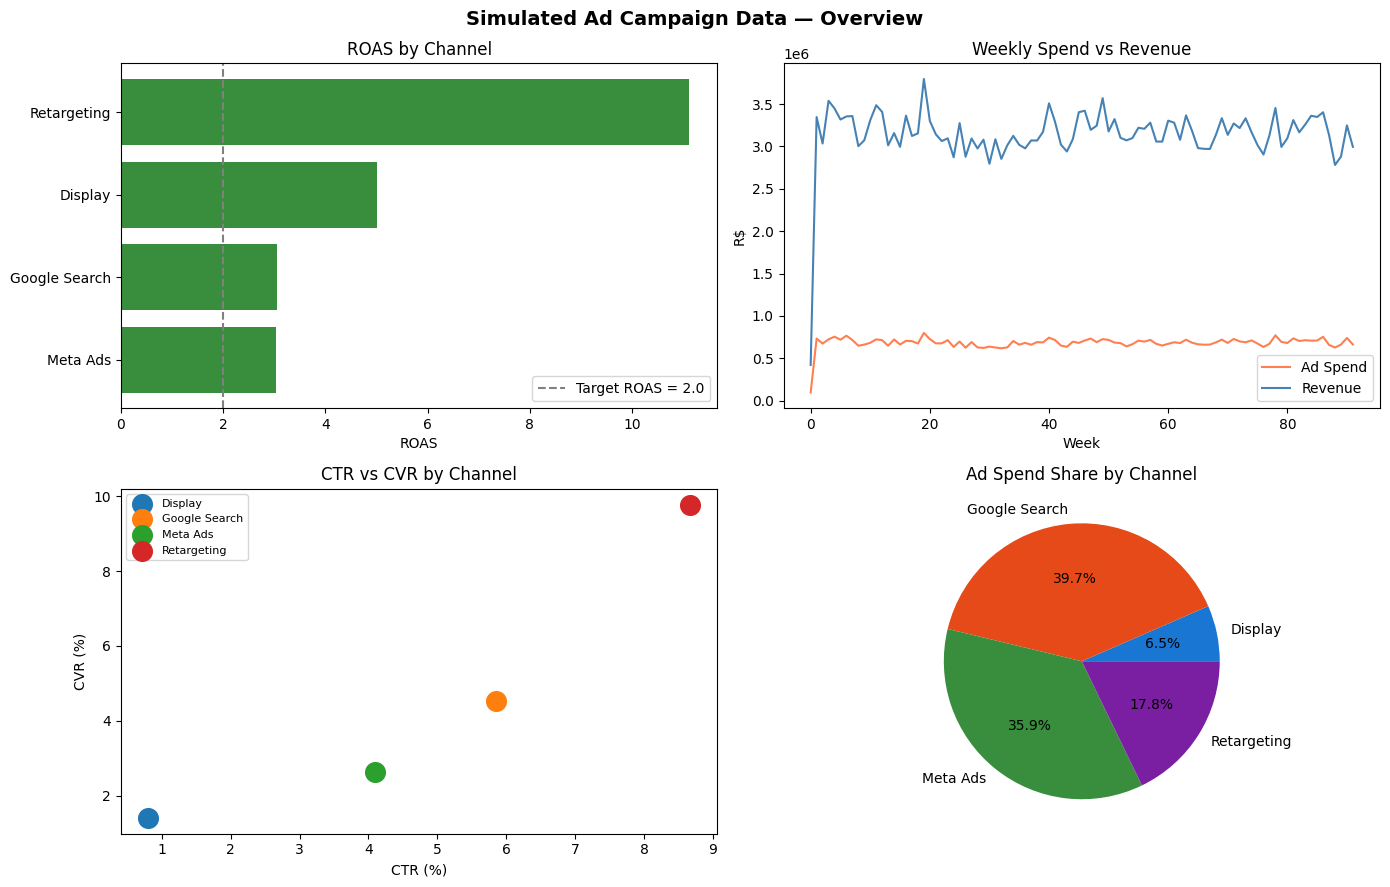

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Simulated Ad Campaign Data — Overview', fontsize=14, fontweight='bold')

# 1. ROAS by channel
roas = summary['roas'].sort_values()
colors = ['#d32f2f' if v < 1.5 else '#f57c00' if v < 2.5 else '#388e3c' for v in roas]
axes[0,0].barh(roas.index, roas.values, color=colors)
axes[0,0].axvline(2.0, color='gray', linestyle='--', label='Target ROAS = 2.0')
axes[0,0].set_title('ROAS by Channel')
axes[0,0].set_xlabel('ROAS')
axes[0,0].legend()

# 2. Weekly spend & revenue trend
ad_df['week'] = pd.to_datetime(ad_df['date']).dt.to_period('W').astype(str)
weekly = ad_df.groupby('week')[['ad_spend','attributed_revenue']].sum()
x = range(len(weekly))
axes[0,1].plot(x, weekly['ad_spend'],          label='Ad Spend',  color='coral')
axes[0,1].plot(x, weekly['attributed_revenue'],label='Revenue',   color='steelblue')
axes[0,1].set_title('Weekly Spend vs Revenue')
axes[0,1].set_xlabel('Week')
axes[0,1].set_ylabel('R$')
axes[0,1].legend()

# 3. CTR vs CVR by channel (scatter)
for ch in summary.index:
    axes[1,0].scatter(summary.loc[ch,'ctr_pct'], summary.loc[ch,'cvr_pct'], s=200, label=ch)
axes[1,0].set_title('CTR vs CVR by Channel')
axes[1,0].set_xlabel('CTR (%)')
axes[1,0].set_ylabel('CVR (%)')
axes[1,0].legend(fontsize=8)

# 4. Spend share by channel (pie)
spend_share = summary['ad_spend']
axes[1,1].pie(spend_share, labels=spend_share.index, autopct='%1.1f%%',
              colors=['#1976D2','#E64A19','#388E3C','#7B1FA2'])
axes[1,1].set_title('Ad Spend Share by Channel')

plt.tight_layout()
plt.savefig(PROC_DIR / 'ad_simulation_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Export

In [7]:
out_path = PROC_DIR / 'ad_campaigns.csv'
ad_df.to_csv(out_path, index=False)

print(f'   Saved: {out_path}')
print(f'   Rows     : {len(ad_df):,}')
print(f'   Columns  : {list(ad_df.columns)}')
print('\n   Next step → run 03_funnel_analysis.ipynb')

   Saved: C:\Users\F0001215\Jupyter Notebook\ecommerce-ad-analytics\data\processed\ad_campaigns.csv
   Rows     : 14,036
   Columns  : ['date', 'campaign_id', 'campaign_name', 'channel', 'product_category_eng', 'impressions', 'clicks', 'ad_spend', 'attributed_orders', 'attributed_revenue', 'week']

   Next step → run 03_funnel_analysis.ipynb
